In [1]:
!apt-get update -qq
!apt-get install -y lammps python3-lammps
!pip install ase

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu noble InRelease' does not seem to provide it (sources.list entry misspelt?)
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following additional packages will be installed:
  fonts-mathjax javascript-common lammps-data lammps-doc lammps-examples
  libdouble-conversion3 libgl2ps1.4 libglew2.2 libjs-mathjax libjs-underscore
  libkim-api2 liblammps-dev liblammps0t64 libpnetcdf0d libtbb12 libtbbbind-2-5
  libtbbmalloc2 libvoro++1 libvtk9.1t64 python3-mpi4py
Suggested packages:
  apache2 | lighttpd | httpd openkim-models glew-utils fonts-mathjax-extras
  fonts-stix libjs-mathjax-doc vtk9-doc vtk9-examples
The following NEW packages will be installed:
  fonts-mathjax javascript-common lammps lammps-data lammps-doc
  lammps-examples libdouble-conversion3 libgl2ps1.4 libglew2.2 libjs-mathjax
  libjs-underscore libkim-api2 liblammp

In [2]:
from ase.build import bulk
from ase.io import write

ti = bulk("Ti", crystalstructure = "hcp", a = 2.95, c = 4.68)

ti = ti.repeat((10, 10, 10))

print(ti.cell)
write("Ti.data", ti, format = "lammps-data", atom_style = "atomic")

print(open("Ti.data").read()[:2000])

Cell([[29.5, 0.0, 0.0], [-14.75, 25.54774941164094, 0.0], [0.0, 0.0, 46.8]])
(written by ASE)

2000 atoms
1 atom types

0.0                    29.5  xlo xhi
0.0       25.54774941164094  ylo yhi
0.0      46.799999999999997  zlo zhi
                 -14.75                       0                       0  xy xz yz

Atoms # atomic

     1   1                       0                       0                       0
     2   1  5.4585965377403533e-17      1.7031832941093958      2.3399999999999999
     3   1                       0                       0      4.6799999999999997
     4   1  5.4585965377403533e-17      1.7031832941093958      7.0199999999999996
     5   1                       0                       0      9.3599999999999994
     6   1  5.4585965377403533e-17      1.7031832941093958      11.699999999999999
     7   1                       0                       0      14.039999999999999
     8   1  5.4585965377403533e-17      1.7031832941093958      16.379999999999999
     9

In [3]:
from google.colab import files

potential = files.upload()

Saving Ti1.eam.fs to Ti1.eam.fs


In [4]:
%%writefile Ti_eam_minimize.in

clear

units metal
dimension 3
boundary p p p
atom_style atomic

read_data Ti.data

mass 1 47.867

pair_style eam/fs
pair_coeff * * Ti1.eam.fs Ti

neighbor 2.0 bin
neigh_modify every 1 delay 0 check yes

thermo 100
thermo_style custom step temp pe ke etotal press vol lx ly lz

fix RELAX all box/relax tri 0.0 vmax 0.001
min_style cg
minimize 1.0e-12 1.0e-12 10000 100000

write_data Ti_minimized.data

write_dump  all custom minimized.lammpstrj id type x y z
write_restart minimized.restart


Writing Ti_eam_minimize.in


In [5]:
!lmp -in Ti_eam_minimize.in

LAMMPS (7 Feb 2024 - Update 1)
OMP_NUM_THREADS environment is not set. Defaulting to 1 thread. (src/comm.cpp:98)
  using 1 OpenMP thread(s) per MPI task
OMP_NUM_THREADS environment is not set. Defaulting to 1 thread. (src/comm.cpp:98)
  using 1 OpenMP thread(s) per MPI task
Reading data file ...
  triclinic box = (0 0 0) to (29.5 25.547749 46.8) with tilt (-14.75 0 0)
  1 by 1 by 1 MPI processor grid
  reading atoms ...
  2000 atoms
  read_data CPU = 0.008 seconds
Neighbor list info ...
  update: every = 1 steps, delay = 0 steps, check = yes
  max neighbors/atom: 2000, page size: 100000
  master list distance cutoff = 8.9
  ghost atom cutoff = 8.9
  binsize = 4.45, bins = 10 6 11
  1 neighbor lists, perpetual/occasional/extra = 1 0 0
  (1) pair eam/fs, perpetual
      attributes: half, newton on
      pair build: half/bin/atomonly/newton/tri
      stencil: half/bin/3d/tri
      bin: standard
Setting up cg style minimization ...
  Unit style    : metal
  Current step  : 0
 (src/min.cpp:

In [6]:
!ls

log.lammps	     minimized.restart	Ti1.eam.fs  Ti_eam_minimize.in
minimized.lammpstrj  sample_data	Ti.data     Ti_minimized.data


In [14]:
import os

file = "log.lammps"

size = os.path.getsize(file)
print(f"File size: {size / (1024**2):.2f} MB")

File size: 0.00 MB


In [15]:
from google.colab import files
download = files.download("log.lammps")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [16]:
%%writefile nvt.in

clear

units metal
dimension 3
boundary p p p
atom_style atomic

read_data Ti_minimized.data

pair_style eam/fs
pair_coeff * * Ti1.eam.fs Ti

neighbor 2.0 bin
neigh_modify delay 0 every 1 check yes

velocity all create 300 49989 mom yes rot no dist gaussian

reset_timestep 0

timestep 0.001

fix NVT all nvt temp 300.0 300.0 0.1

thermo 1000
thermo_style custom step temp pe ke etotal press vol lx ly lz

run 50000

write_restart nvt_300k.restart
write_data nvt_300k.data
write_dump  all custom nvt_300k.lammpstrj id type x y z

Writing nvt.in


In [17]:
!lmp -in nvt.in

LAMMPS (7 Feb 2024 - Update 1)
OMP_NUM_THREADS environment is not set. Defaulting to 1 thread. (src/comm.cpp:98)
  using 1 OpenMP thread(s) per MPI task
OMP_NUM_THREADS environment is not set. Defaulting to 1 thread. (src/comm.cpp:98)
  using 1 OpenMP thread(s) per MPI task
Reading data file ...
  triclinic box = (0.017327177 0.015005687 -0.12152901) to (29.482673 25.532744 46.921529) with tilt (-14.732645 1.31987e-15 7.4683543e-16)
  1 by 1 by 1 MPI processor grid
  reading atoms ...
  2000 atoms
  reading velocities ...
  2000 velocities
  read_data CPU = 0.045 seconds
Neighbor list info ...
  update: every = 1 steps, delay = 0 steps, check = yes
  max neighbors/atom: 2000, page size: 100000
  master list distance cutoff = 8.9
  ghost atom cutoff = 8.9
  binsize = 4.45, bins = 10 6 11
  1 neighbor lists, perpetual/occasional/extra = 1 0 0
  (1) pair eam/fs, perpetual
      attributes: half, newton on
      pair build: half/bin/atomonly/newton/tri
      stencil: half/bin/3d/tri
      

In [18]:
!ls

log.lammps	     nvt_300k.data	 nvt.in       Ti.data
minimized.lammpstrj  nvt_300k.lammpstrj  sample_data  Ti_eam_minimize.in
minimized.restart    nvt_300k.restart	 Ti1.eam.fs   Ti_minimized.data


In [23]:
from google.colab import files
downloaded = files.download("nvt.in")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [19]:
print(open("log.lammps").read()[:5000])

LAMMPS (7 Feb 2024 - Update 1)
OMP_NUM_THREADS environment is not set. Defaulting to 1 thread. (src/comm.cpp:98)
  using 1 OpenMP thread(s) per MPI task

clear
OMP_NUM_THREADS environment is not set. Defaulting to 1 thread. (src/comm.cpp:98)
  using 1 OpenMP thread(s) per MPI task

units metal
dimension 3
boundary p p p
atom_style atomic

read_data Ti_minimized.data
Reading data file ...
  triclinic box = (0.017327177 0.015005687 -0.12152901) to (29.482673 25.532744 46.921529) with tilt (-14.732645 1.31987e-15 7.4683543e-16)
  1 by 1 by 1 MPI processor grid
  reading atoms ...
  2000 atoms
  reading velocities ...
  2000 velocities
  read_data CPU = 0.045 seconds

pair_style eam/fs
pair_coeff * * Ti1.eam.fs Ti

neighbor 2.0 bin
neigh_modify delay 0 every 1 check yes

velocity all create 300 49989 mom yes rot no dist gaussian

reset_timestep 0

timestep 0.001

fix NVT all nvt temp 300.0 300.0 0.1

thermo 1000
thermo_style custom step temp pe ke etotal press vol lx ly lz

run 50000
Neigh

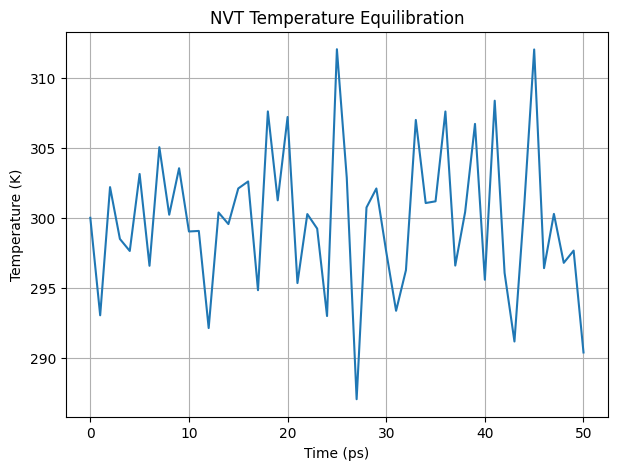

In [24]:
import numpy as np
import matplotlib.pyplot as plt

# Read LAMMPS log
filename = "log.lammps"

data = []

with open(filename, "r") as f:
    reading = False

    for line in f:
        line = line.strip()

        if line.startswith("Step"):
            reading = True
            continue

        if reading:
            parts = line.split()

            if len(parts) == 10:
                try:
                    data.append([float(x) for x in parts])
                except ValueError:
                    reading = False
            else:
                reading = False

data = np.array(data)

# Columns
step   = data[:, 0]
temp   = data[:, 1]
pe     = data[:, 2]
ke     = data[:, 3]
etotal = data[:, 4]
press  = data[:, 5]
vol    = data[:, 6]
lx     = data[:, 7]
ly     = data[:, 8]
lz     = data[:, 9]

# Convert timestep to ps
time = step * 0.001

plt.figure(figsize=(7,5))

plt.plot(time, temp)

plt.xlabel("Time (ps)")
plt.ylabel("Temperature (K)")
plt.title("NVT Temperature Equilibration")

plt.grid()
plt.show()

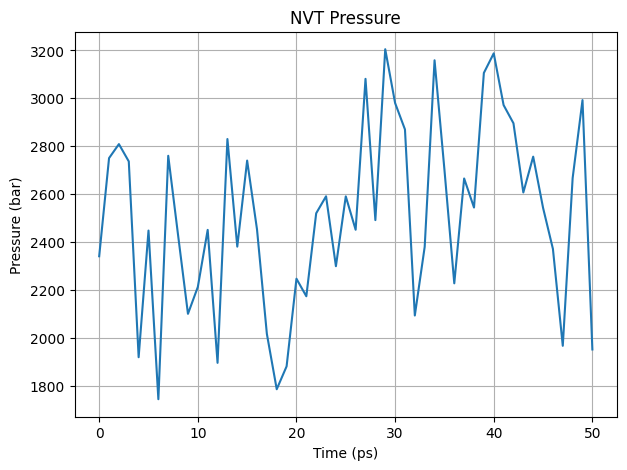

In [ ]:
plt.figure(figsize=(7,5))

plt.plot(time, press)

plt.xlabel("Time (ps)")
plt.ylabel("Pressure (bar)")
plt.title("NVT Pressure")

plt.grid()
plt.show()

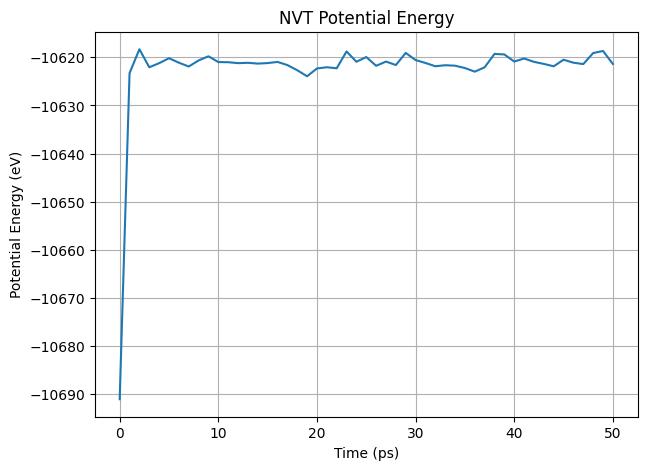

In [ ]:
plt.figure(figsize=(7,5))

plt.plot(time, pe)

plt.xlabel("Time (ps)")
plt.ylabel("Potential Energy (eV)")
plt.title("NVT Potential Energy")

plt.grid()
plt.show()

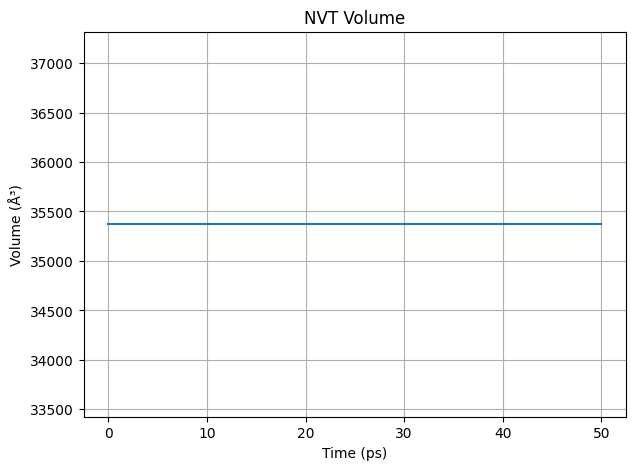

In [ ]:

plt.figure(figsize=(7,5))

plt.plot(time, vol)

plt.xlabel("Time (ps)")
plt.ylabel("Volume (Å³)")
plt.title("NVT Volume")

plt.grid()
plt.show()

In [25]:
%%writefile NPT.in

clear

units metal
dimension 3
boundary p p p
atom_style atomic

read_data nvt_300k.data

pair_style eam/fs
pair_coeff * * Ti1.eam.fs Ti

neighbor 2.0 bin
neigh_modify delay 0 every 1 check yes

reset_timestep 0

timestep 0.001

fix NPT all npt temp 300.0 300.0 0.1 iso 0.0 0.0 1.0

thermo 1000
thermo_style custom step temp pe ke etotal vol lx ly lz

run 100000

write_restart npt_300k_0bar.restart
write_data npt_300k_0bar.data

Writing NPT.in


In [26]:
!lmp -in NPT.in

LAMMPS (7 Feb 2024 - Update 1)
OMP_NUM_THREADS environment is not set. Defaulting to 1 thread. (src/comm.cpp:98)
  using 1 OpenMP thread(s) per MPI task
OMP_NUM_THREADS environment is not set. Defaulting to 1 thread. (src/comm.cpp:98)
  using 1 OpenMP thread(s) per MPI task
Reading data file ...
  triclinic box = (0.017327177 0.015005687 -0.12152901) to (29.482673 25.532744 46.921529) with tilt (-14.732645 1.31987e-15 7.4683543e-16)
  1 by 1 by 1 MPI processor grid
  reading atoms ...
  2000 atoms
  reading velocities ...
  2000 velocities
  read_data CPU = 0.014 seconds
Neighbor list info ...
  update: every = 1 steps, delay = 0 steps, check = yes
  max neighbors/atom: 2000, page size: 100000
  master list distance cutoff = 8.9
  ghost atom cutoff = 8.9
  binsize = 4.45, bins = 10 6 11
  1 neighbor lists, perpetual/occasional/extra = 1 0 0
  (1) pair eam/fs, perpetual
      attributes: half, newton on
      pair build: half/bin/atomonly/newton/tri
      stencil: half/bin/3d/tri
      

In [27]:
!ls

log.lammps	       NPT.in		   sample_data
minimized.lammpstrj    nvt_300k.data	   Ti1.eam.fs
minimized.restart      nvt_300k.lammpstrj  Ti.data
npt_300k_0bar.data     nvt_300k.restart    Ti_eam_minimize.in
npt_300k_0bar.restart  nvt.in		   Ti_minimized.data


In [33]:
from google.colab import files
downloaded = files.download("log.lammps")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [34]:
%%writefile strain.in

clear
units metal
dimension 3
boundary p p p
atom_style atomic

read_data npt_300k_0bar.data

pair_style eam/fs
pair_coeff * * Ti1.eam.fs Ti

neighbor 2.0 bin
neigh_modify every 1 delay 0 check yes

timestep 0.001                     # ps (1 fs)

thermo 1000
thermo_style custom step temp pe ke etotal press pxx pyy pzz lx ly lz xy

# Initial box
variable Lz0 equal $(lz)

# Strain settings
variable rate equal 0.001           # 1/ps  (1e9 1/s)
variable target_strain equal -0.10
variable nsteps equal round(abs(v_target_strain/v_rate)/dt)

# Thermostat + lateral barostat (x, y at 0 bar), z controlled by deform
fix BARO all npt temp 300.0 300.0 0.1 x 0.0 0.0 1.0 y 0.0 0.0 1.0 couple none

# Compress z at constant engineering strain rate
fix DEF all deform 1 z erate -${rate} units box remap x

# Outputs
variable strain_z equal (lz-v_Lz0)/v_Lz0
variable sxx_GPa equal -pxx/10000.0
variable syy_GPa equal -pyy/10000.0
variable szz_GPa equal -pzz/10000.0

fix OUT all print 100 "${strain_z} ${sxx_GPa} ${syy_GPa} ${szz_GPa}" &
    file z_compressed.data screen no title "# strain_z sxx syy szz (GPa)"

dump TRAJ all custom 1000 ti_z_compressed.lammpstrj id type x y z
dump_modify TRAJ sort id

run ${nsteps}

unfix DEF
unfix OUT
unfix BARO
undump TRAJ

Writing strain.in


In [35]:
!lmp -in strain.in

LAMMPS (7 Feb 2024 - Update 1)
OMP_NUM_THREADS environment is not set. Defaulting to 1 thread. (src/comm.cpp:98)
  using 1 OpenMP thread(s) per MPI task
OMP_NUM_THREADS environment is not set. Defaulting to 1 thread. (src/comm.cpp:98)
  using 1 OpenMP thread(s) per MPI task
Reading data file ...
  triclinic box = (-0.00045927799 -0.00039783553 -0.14992607) to (29.500459 25.548147 46.949926) with tilt (-14.750432 1.3214634e-15 7.4773706e-16)
  1 by 1 by 1 MPI processor grid
  reading atoms ...
  2000 atoms
  reading velocities ...
  2000 velocities
  read_data CPU = 0.014 seconds
Neighbor list info ...
  update: every = 1 steps, delay = 0 steps, check = yes
  max neighbors/atom: 2000, page size: 100000
  master list distance cutoff = 8.9
  ghost atom cutoff = 8.9
  binsize = 4.45, bins = 10 6 11
  1 neighbor lists, perpetual/occasional/extra = 1 0 0
  (1) pair eam/fs, perpetual
      attributes: half, newton on
      pair build: half/bin/atomonly/newton/tri
      stencil: half/bin/3d/tr

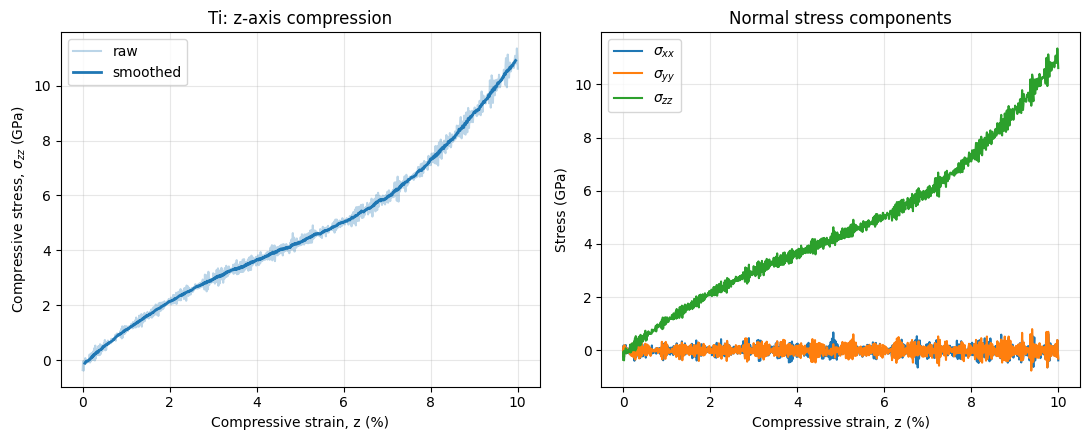

Peak compressive stress: 10.94 GPa at 9.95% strain
Estimated modulus (0-1% strain): 129.6 GPa


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Load data: columns = strain_z, sxx, syy, szz (GPa); the "#" title line is skipped
data = np.loadtxt("z_compressed.data", comments="#")
strain = data[:, 0]
sxx, syy, szz = data[:, 1], data[:, 2], data[:, 3]

# Optional: moving-average smoothing to reduce thermal noise
def smooth(y, w=10):
    return np.convolve(y, np.ones(w) / w, mode="same")

# Compressive convention: plot positive stress vs positive strain
eps = -strain * 100          # percent
sig_z = -szz                 # GPa (compressive = positive)

fig, ax = plt.subplots(1, 2, figsize=(11, 4.5))

# Left: stress-strain curve along z
ax[0].plot(eps, sig_z, alpha=0.3, color="C0", label="raw")
ax[0].plot(eps[5:-5], smooth(sig_z)[5:-5], color="C0", lw=2, label="smoothed")
ax[0].set_xlabel("Compressive strain, z (%)")
ax[0].set_ylabel("Compressive stress, $\\sigma_{zz}$ (GPa)")
ax[0].set_title("Ti: z-axis compression")
ax[0].legend()
ax[0].grid(alpha=0.3)

# Right: all normal stress components
ax[1].plot(eps, -sxx, label="$\\sigma_{xx}$")
ax[1].plot(eps, -syy, label="$\\sigma_{yy}$")
ax[1].plot(eps, -szz, label="$\\sigma_{zz}$")
ax[1].set_xlabel("Compressive strain, z (%)")
ax[1].set_ylabel("Stress (GPa)")
ax[1].set_title("Normal stress components")
ax[1].legend()
ax[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig("stress_strain_z.png", dpi=300)
plt.show()

# Quick numbers: peak stress and where it occurs
i = np.argmax(smooth(sig_z)[5:-5]) + 5
print(f"Peak compressive stress: {sig_z[i]:.2f} GPa at {eps[i]:.2f}% strain")

# Young's modulus from the initial linear region (0 to 1% strain)
mask = eps <= 1.0
E = np.polyfit(eps[mask] / 100, sig_z[mask], 1)[0]
print(f"Estimated modulus (0-1% strain): {E:.1f} GPa")

In [36]:
!ls

log.lammps	       nvt_300k.data	   Ti1.eam.fs
minimized.lammpstrj    nvt_300k.lammpstrj  Ti.data
minimized.restart      nvt_300k.restart    Ti_eam_minimize.in
npt_300k_0bar.data     nvt.in		   Ti_minimized.data
npt_300k_0bar.restart  sample_data	   ti_z_compressed.lammpstrj
NPT.in		       strain.in	   z_compressed.data


In [40]:
from google.colab import files
download = files.download("strain.in")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Columns: strain_z, sxx, syy, szz (GPa)
data = np.loadtxt("z_compressed.data", comments="#")
eps = -data[:, 0] * 100      # compressive strain (%)
sig = -data[:, 3]            # compressive stress (GPa)

# Moving-average smoothing
w = 10
sig_s = np.convolve(sig, np.ones(w) / w, mode="valid")
eps_s = eps[w // 2 : w // 2 + len(sig_s)]   # keep x aligned with the smoothed y

plt.figure(figsize=(5.5, 4.5))
plt.plot(eps_s, sig_s, lw=2, color="C0")
plt.xlabel("Compressive strain (%)")
plt.ylabel("Compressive stress (GPa)")
plt.title("Ti: z-axis compression")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("stress_strain_z.png", dpi=300)
plt.show()

# Fix print output for fix OUT
0 1.0560116272315899573e-15 0.2321391027149790065 0.18569606803428098663 0.35594635979534000603
100 -9.999999999892599412e-05 -0.18192872101712900812 -0.14542964478052800015 0.03801367162568729946
200 -0.00019999999999890800116 0.25731664242335300363 0.24079260857812098684 0.37709424636266697384
300 -0.00029999999999889002174 -0.16664114234424098893 -0.19173373908238899865 0.027899373103749500191
400 -0.00039999999999887201523 0.048488468805897896874 0.10096222799953200044 0.10097787167807399655
500 -0.00049999999999885400871 -0.02656198898640349873 -0.012534584542787099645 0.051670772486945799884
600 -0.00059999999999883594799 -0.19982993791702399755 -0.11609669333588699958 -0.077574101562743302818
700 -0.00069999999999881799568 0.0068646218371522299204 0.050728517140483098125 0.11798939541995000224
800 -0.00079999999999880004337 -0.064397970632604398245 -0.081443341647468400768 -0.011835972638188200362
900 -0.00089999999999893301201 0.084695984118274503

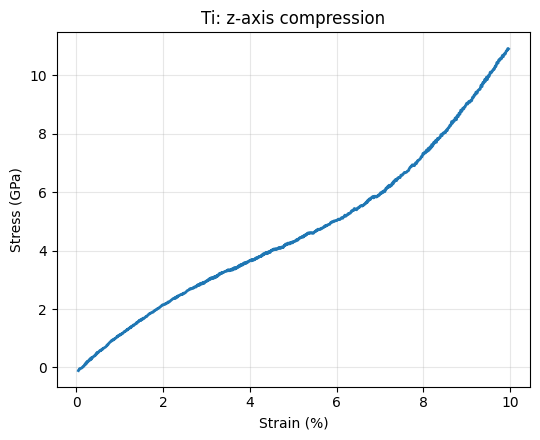

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Columns: strain_z, sxx, syy, szz (GPa)
data = np.loadtxt("z_compressed.data", comments="#")
eps = -data[:, 0] * 100      # compressive strain (%)
sig = -data[:, 3]            # compressive stress (GPa)

# Moving-average smoothing
w = 10
sig_s = np.convolve(sig, np.ones(w) / w, mode="valid")
eps_s = eps[w // 2 : w // 2 + len(sig_s)]   # keep x aligned with the smoothed y

plt.figure(figsize=(5.5, 4.5))
plt.plot(eps_s, sig_s, lw=2, color="C0")
plt.xlabel("Strain (%)")
plt.ylabel("Stress (GPa)")
plt.title("Ti: z-axis compression")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("stress_strain_z.png", dpi=300)
plt.show()